# Credit Card Fraud Detection

The dataset contains transactions made by credit cards in September 2013 by European cardholders.

# Libraries

In [18]:
!pip -q install xgboost

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_auc_score, auc,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv(r'/Users/festusattornelson/Documents/Projects/Python MSIT/CreditCard/creditcard.csv')
df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.isna().sum().sum()

0

In [5]:
df.shape

(284807, 31)

In [8]:
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Class distribution:\n{df['Class'].value_counts()}")
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%\n")

Dataset: 284,807 rows x 31 cols
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.173%



# Exploratory Data Analysis (EDA)

In [9]:
#df.describe()

In [10]:
df.Time.value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
127750.0     1
62260.0      1
62259.0      1
127753.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

# Preprocessing

In [11]:
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"]   = scaler.fit_transform(df[["Time"]])

In [14]:
X = df.drop(columns=["Class"])
y = df["Class"]

***Train | Test Split***

In [15]:
# Stratified split — preserves fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 227,845 rows | Test: 56,962 rows


# Handle class imbalance with SMOTE

***Applied to training set only — never touch the test set***

In [20]:
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — training class distribution:")
print(pd.Series(y_train_res).value_counts())


After SMOTE — training class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


# Shared evaluation function 

In [21]:
def evaluate_model(name, y_true, y_pred, y_prob):
    cm        = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)
    auc_pr    = auc(rec_c, prec_c)
    auc_roc   = roc_auc_score(y_true, y_prob)
 
    return {
        "Model":     name,
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1":        round(f1, 4),
        "AUC-PR":    round(auc_pr, 4),
        "AUC-ROC":   round(auc_roc, 4),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "_prob":  y_prob,
        "_prec_curve": prec_c,
        "_rec_curve":  rec_c,
        "_cm": cm,
    }
 
results = {}
THRESHOLD = 0.30   # lower than 0.5 to favour recall

# Model 1 — Logistic Regression 

In [22]:
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_res, y_train_res)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= THRESHOLD).astype(int)
results["Logistic Regression"] = evaluate_model(
    "Logistic Regression", y_test, lr_pred, lr_prob
)
 


Training Logistic Regression...


# Model 2 — Random Forest 

In [23]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_res, y_train_res)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= THRESHOLD).astype(int)
results["Random Forest"] = evaluate_model(
    "Random Forest", y_test, rf_pred, rf_prob
)
 

Training Random Forest...


# Model 3 — XGBoost 

In [24]:
print("Training XGBoost...")
scale_pos = (y_train_res == 0).sum() / (y_train_res == 1).sum()
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="aucpr",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_train_res, y_train_res)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= THRESHOLD).astype(int)
results["XGBoost"] = evaluate_model(
    "XGBoost", y_test, xgb_pred, xgb_prob
)

Training XGBoost...


# Model 4 — SVM 

In [25]:
print("Training SVM (sampling 5,000 rows for speed)...")
# SVM is slow on 200k+ rows; subsample for training
rng = np.random.RandomState(42)
svm_idx = rng.choice(len(X_train_res), size=min(5000, len(X_train_res)), replace=False)
svm = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42,
)
svm.fit(X_train_res.iloc[svm_idx], y_train_res.iloc[svm_idx])
svm_prob = svm.predict_proba(X_test)[:, 1]
svm_pred = (svm_prob >= THRESHOLD).astype(int)
results["SVM"] = evaluate_model(
    "SVM", y_test, svm_pred, svm_prob
)

Training SVM (sampling 5,000 rows for speed)...


#  Summary table

In [26]:
summary_cols = ["Model", "Precision", "Recall", "F1", "AUC-PR", "AUC-ROC"]
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in summary_cols}
    for r in results.values()
])
print("\n" + "="*60)
print("  MODEL COMPARISON RESULTS")
print("="*60)
print(summary_df.to_string(index=False))
 
cm_df = pd.DataFrame([
    {"Model": r["Model"], "TP": r["TP"], "FP": r["FP"],
     "FN": r["FN"], "TN": r["TN"]}
    for r in results.values()
])
print("\nConfusion matrix counts:")
print(cm_df.to_string(index=False))


  MODEL COMPARISON RESULTS
              Model  Precision  Recall     F1  AUC-PR  AUC-ROC
Logistic Regression     0.0273  0.9184 0.0530  0.7703   0.9698
      Random Forest     0.7395  0.8980 0.8111  0.8765   0.9762
            XGBoost     0.2005  0.9082 0.3284  0.8493   0.9758
                SVM     0.0308  0.9184 0.0596  0.6169   0.9812

Confusion matrix counts:
              Model  TP   FP  FN    TN
Logistic Regression  90 3208   8 53656
      Random Forest  88   31  10 56833
            XGBoost  89  355   9 56509
                SVM  90 2830   8 54034


# Plot 1 — Metric bar chart 

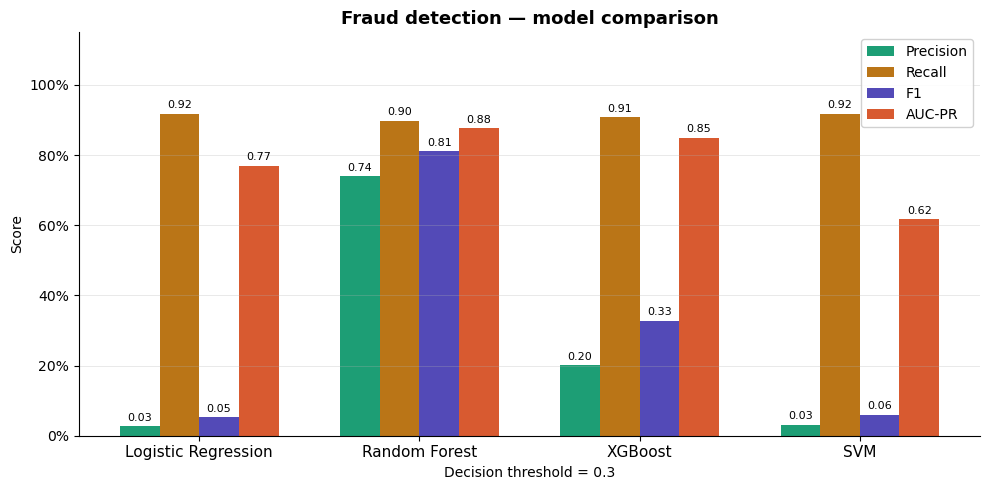

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics  = ["Precision", "Recall", "F1", "AUC-PR"]
colors   = ["#1D9E75", "#BA7517", "#534AB7", "#D85A30"]
x        = np.arange(len(results))
width    = 0.18
 
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [r[metric] for r in results.values()]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8
        )
 
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(list(results.keys()), fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Fraud detection — model comparison", fontsize=13, fontweight="bold")
ax.set_xlabel(f"Decision threshold = {THRESHOLD}")
ax.legend(loc="upper right", framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fraud_model_comparison.png", dpi=150)
plt.show()

# Plot 2 — Precision-Recall curves

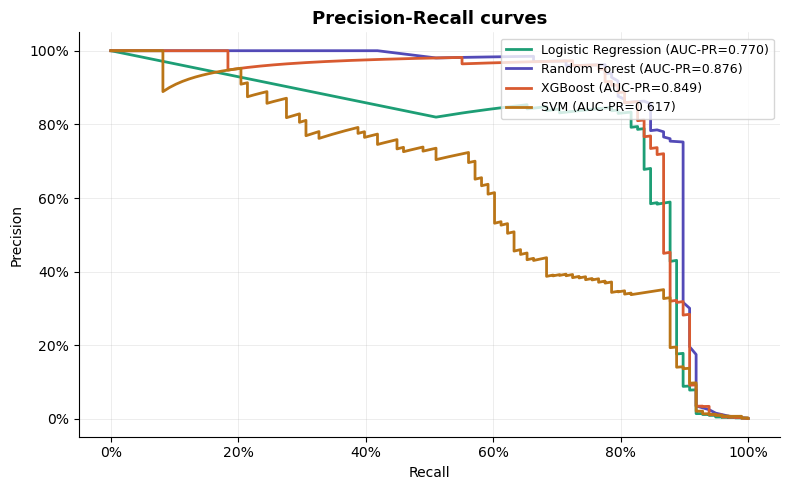

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
line_colors = {
    "Logistic Regression": "#1D9E75",
    "Random Forest":       "#534AB7",
    "XGBoost":             "#D85A30",
    "SVM":                 "#BA7517",
}
for name, r in results.items():
    ax.plot(
        r["_rec_curve"], r["_prec_curve"],
        label=f"{name} (AUC-PR={r['AUC-PR']:.3f})",
        color=line_colors[name], linewidth=2,
    )
 
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(linewidth=0.4, alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fraud_pr_curves.png", dpi=150)
plt.show()

# Plot 3 — Confusion matrices (2x2 grid)

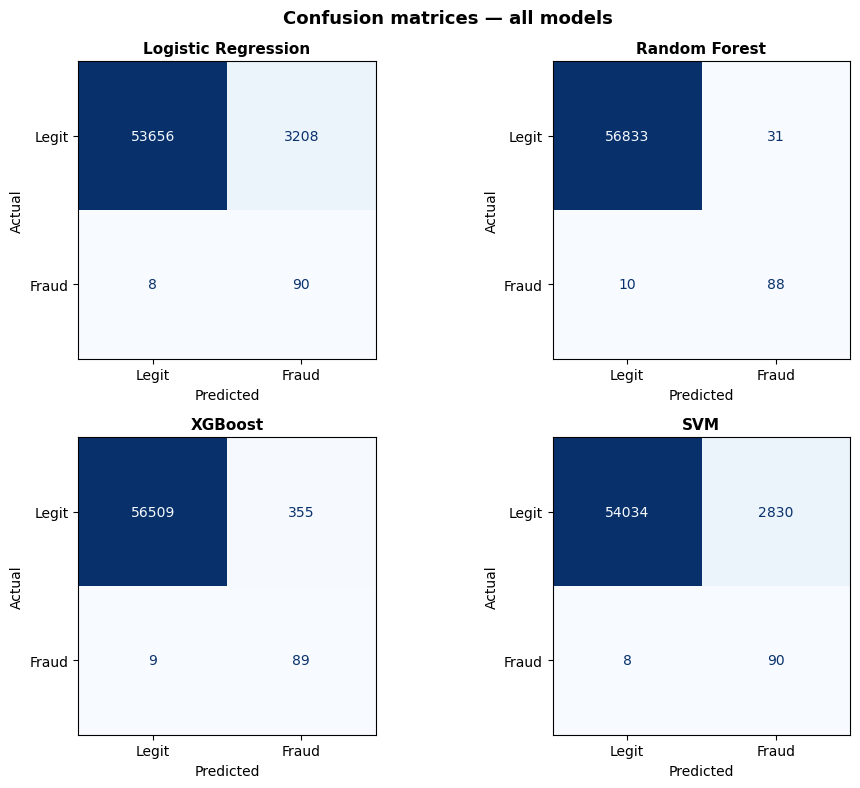

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Confusion matrices — all models", fontsize=13, fontweight="bold")
 
for ax, (name, r) in zip(axes.flatten(), results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r["_cm"],
        display_labels=["Legit", "Fraud"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
 
plt.tight_layout()
plt.savefig("fraud_confusion_matrices.png", dpi=150)
plt.show()

# Plot 4 — Random Forest feature importance 

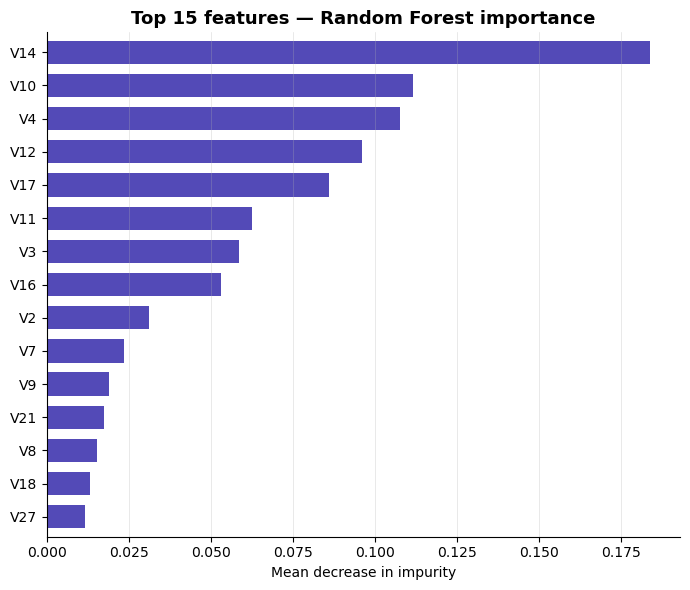


Done. Plots saved to working directory.


In [30]:
feat_imp = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)
 
fig, ax = plt.subplots(figsize=(7, 6))
feat_imp[::-1].plot(kind="barh", ax=ax, color="#534AB7", width=0.7)
ax.set_title("Top 15 features — Random Forest importance",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean decrease in impurity")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("fraud_feature_importance.png", dpi=150)
plt.show()
 
print("\nDone. Plots saved to working directory.")